# Recyclable Waste Material Classification

The dataset used can be found on the Hugging Face website at https://huggingface.co/datasets/garythung/trashnet/tree/main .

A GitHub repository by the original creator of the dataset is on https://github.com/garythung/trashnet .

To download the dataset locally, go to the 'Files and Versions' tab and click the download button next to 'dataset-original.zip'. The zip file will need to be uploaded to your Drive to load on this notebook.

This notebook includes code modified from https://github.com/nachi-hebbar/Transfer-Learning-ResNet-Keras and  https://github.com/KamiriTech/Loading-and-Pre-processing-Image-Datasets-in-Google-colab-

### Data Preprocessing

In [41]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
import tf_keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [22]:
# Splitting data into training and validation sets with 20% for validation.
dataset=tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original')
ds_train = tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original',
        validation_split=0.2,
        subset="training",
        seed=123)
ds_validation = tf.keras.preprocessing.image_dataset_from_directory(
        'dataset-original',
        validation_split=0.2,
        subset="validation",
        seed=123)

Found 2529 files belonging to 6 classes.
Found 2529 files belonging to 6 classes.
Using 2024 files for training.
Found 2529 files belonging to 6 classes.
Using 505 files for validation.


In [23]:
# Define batch size and print labels

batch_size = 32

dataset_name = dataset
class_names = dataset_name.class_names
print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [24]:
# Resizing and standardizing
# x = images, y = labels
size = (224, 224)

ds_train = ds_train.map(lambda x, y: (tf.image.resize(x, size), y))
ds_validation = ds_validation.map(lambda x, y: (tf.image.resize(x, size), y))

In [43]:
# Add data augmentation for training
def augment_data(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    return image, label

ds_train = ds_train.map(augment_data)

In [55]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train_processed = ds_train.prefetch(AUTOTUNE)
ds_validation = ds_validation.prefetch(AUTOTUNE)

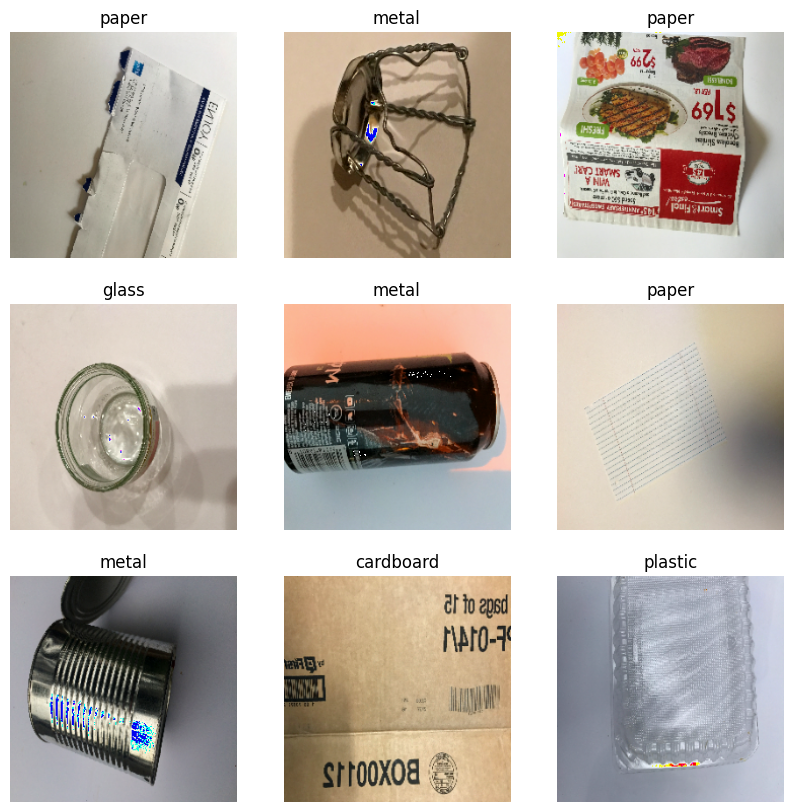

In [56]:
# Display first 9 images

plt.figure(figsize=(10, 10))
for x, y in ds_train.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(x[i].numpy().astype("uint8"))
    plt.title(class_names[y[i]])
    plt.axis("off")

## Testing pre-trained ResNet-50 model

In [45]:
# Instead of freezing all layers, try this approach:
pretrained_model = tf_keras.applications.ResNet50(
    include_top=False,
    input_shape=(224,224,3),
    pooling=None, # removed avg to be able to use GlobalAveragePooling2D
    weights='imagenet'
)

# Unfreeze the last few layers for fine-tuning
for layer in pretrained_model.layers[:-20]:  # Freeze first layers
    layer.trainable = False
for layer in pretrained_model.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True

resnet_model = tf_keras.Sequential([
    pretrained_model,
    tf_keras.layers.GlobalAveragePooling2D(),  # Better than Flatten
    tf_keras.layers.Dropout(0.5),
    tf_keras.layers.Dense(256, activation='relu'),
    tf_keras.layers.Dropout(0.3),
    tf_keras.layers.Dense(6, activation='softmax')
])

In [46]:
resnet_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d_3  (None, 2048)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_6 (Dropout)         (None, 2048)              0         
                                                                 
 dense_6 (Dense)             (None, 256)               524544    
                                                                 
 dropout_7 (Dropout)         (None, 256)               0         
                                                                 
 dense_7 (Dense)             (None, 6)                 1542      
                                                      

In [47]:
resnet_model.compile(
    optimizer=tf_keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
epochs=10
history = resnet_model.fit(
  ds_train,
  validation_data=ds_validation,
  epochs=epochs
)

Epoch 1/10
64/64 [==============================] - 91s 1s/step - loss: 1.3676 - accuracy: 0.4995 - val_loss: 0.6748 - val_accuracy: 0.7248
Epoch 2/10
64/64 [==============================] - 84s 1s/step - loss: 0.5980 - accuracy: 0.7880 - val_loss: 0.5047 - val_accuracy: 0.8198
Epoch 3/10
64/64 [==============================] - 84s 1s/step - loss: 0.3399 - accuracy: 0.8819 - val_loss: 0.4946 - val_accuracy: 0.8515
Epoch 4/10
64/64 [==============================] - 84s 1s/step - loss: 0.2112 - accuracy: 0.9308 - val_loss: 0.4890 - val_accuracy: 0.8376
Epoch 5/10
64/64 [==============================] - 85s 1s/step - loss: 0.1294 - accuracy: 0.9565 - val_loss: 0.5430 - val_accuracy: 0.8396
Epoch 6/10
64/64 [==============================] - 85s 1s/step - loss: 0.0670 - accuracy: 0.9822 - val_loss: 0.4916 - val_accuracy: 0.8673
Epoch 7/10
64/64 [==============================] - 85s 1s/step - loss: 0.0443 - accuracy: 0.9901 - val_loss: 0.5733 - val_accuracy: 0.8554
Epoch 8/10
64/64 [==

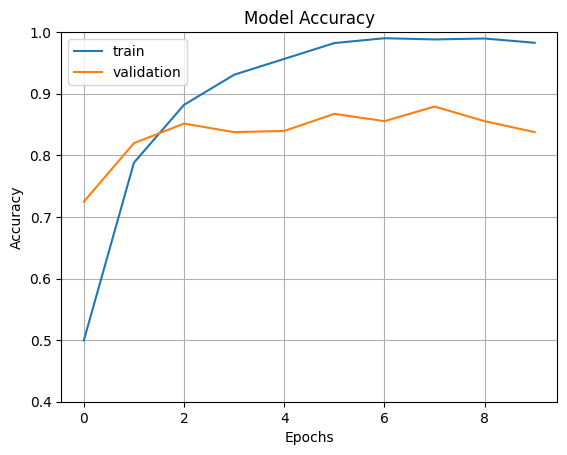

In [49]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

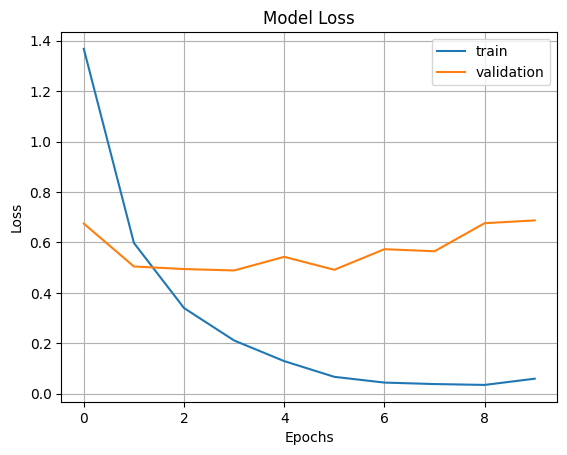

In [50]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [51]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [52]:
# Get predictions on validation set
print("Making predictions on validation set...")
y_pred_probs = resnet_model.predict(ds_validation)
y_pred = np.argmax(y_pred_probs, axis=1)

Making predictions on validation set...
16/16 [==============================] - 16s 861ms/step


In [53]:
# Get true labels from validation dataset
y_true = []
for images, labels in ds_validation:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

print(f"Number of predictions: {len(y_pred)}")
print(f"Number of true labels: {len(y_true)}")

Number of predictions: 505
Number of true labels: 505


In [54]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')
error_rate = 1 - accuracy

print("\n" + "="*50)
print("MODEL EVALUATION METRICS")
print("="*50)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print(f"Error Rate: {error_rate:.4f} ({error_rate*100:.2f}%)")


MODEL EVALUATION METRICS
Accuracy: 0.2040 (20.40%)
Precision (weighted): 0.2083
Recall (weighted): 0.2040
F1-Score (weighted): 0.2056
Error Rate: 0.7960 (79.60%)


### ignore leftover testing in colab

In [ ]:
!pip install streamlit

In [ ]:
%%writefile app.py
import streamlit as st
import streamlit as st


@st.cache(allow_output_mutation=True)
def load_model():
  model=tf.keras.models.load_model('/content/final_model.hdf5')
  return model
with st.spinner('Model is being loaded..'):
  model=load_model()

st.write("""
         # Recyclable Waste Classification
         """
         )

file = st.file_uploader("Please upload an image file", type=["jpg", "png"])

from PIL import Image, ImageOps

st.set_option('deprecation.showfileUploaderEncoding', False)
def import_and_predict(image_data, model):

        size = (180,180)
        image = ImageOps.fit(image_data, size, Image.ANTIALIAS)
        image = np.asarray(image)
        img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #img_resize = (cv2.resize(img, dsize=(75, 75),    interpolation=cv2.INTER_CUBIC))/255.

        img_reshape = img[np.newaxis,...]

        prediction = model.predict(img_reshape)

        return prediction
if file is None:
    st.text("Please upload an image file")
else:
    image = Image.open(file)
    st.image(image, use_column_width=True)
    predictions = import_and_predict(image, model)
    score = tf.nn.softmax(predictions[0])
    st.write(prediction)
    st.write(score)
    print(
    "This image is most likely {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

In [ ]:
!pip install pyngrok

In [ ]:
!ngrok authtoken #Insert Authentication Token here, obtained from Ngrok